<a href="https://colab.research.google.com/github/jaumg2004/xGMobile/blob/main/TrabalhoFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Sistema de Análise de Crédito  
Nomes: Kauã de Oliveira Ribeiro, João Gabriel F. Ribeiro

In [1]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.6 MB/s eta 0:00:00


In [11]:
# Importando as bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from category_encoders import TargetEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [3]:
# Importa os arquivos csv com os dados dos clientes
app_df = pd.read_csv("application_record.csv")
credit_df = pd.read_csv("credit_record.csv")

In [4]:
print("Tabela de Aplicações:")
display(app_df)

print("\nTabela de Histórico de Crédito:")
display(credit_df)

Tabela de Aplicações:


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438552,6840104,M,N,Y,0,135000.0,Pensioner,Secondary / secondary special,Separated,House / apartment,-22717,365243,1,0,0,0,NaN,1.0
438553,6840222,F,N,N,0,103500.0,Working,Secondary / secondary special,Single / not married,House / apartment,-15939,-3007,1,0,0,0,Laborers,1.0
438554,6841878,F,N,N,0,54000.0,Commercial associate,Higher education,Single / not married,With parents,-8169,-372,1,1,0,0,Sales staff,1.0
438555,6842765,F,N,Y,0,72000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-21673,365243,1,0,0,0,NaN,2.0



Tabela de Histórico de Crédito:


,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C
...,...,...,...
1048570,5150487,-25,C
1048571,5150487,-26,C
1048572,5150487,-27,C
1048573,5150487,-28,C


In [5]:
# ==========================================
# CÉLULA 1: LIMPEZA E ENGENHARIA DE DADOS
# ==========================================

# 1. Renomeando colunas do application_record para um português intuitivo
app_df.rename(columns={
    'CODE_GENDER': 'Genero',
    'FLAG_OWN_CAR': 'Tem_Carro',
    'FLAG_OWN_REALTY': 'Tem_Imovel',
    'CNT_CHILDREN': 'Qtd_Filhos',
    'AMT_INCOME_TOTAL': 'Renda_Anual',
    'NAME_INCOME_TYPE': 'Tipo_Renda',
    'NAME_EDUCATION_TYPE': 'Escolaridade',
    'NAME_FAMILY_STATUS': 'Estado_Civil',
    'NAME_HOUSING_TYPE': 'Tipo_Moradia',
    'DAYS_BIRTH': 'Idade',
    'DAYS_EMPLOYED': 'Anos_Empregado',
    'FLAG_MOBIL': 'Tem_Celular',
    'FLAG_WORK_PHONE': 'Tem_Tel_Trabalho',
    'FLAG_PHONE': 'Tem_Tel_Fixo',
    'FLAG_EMAIL': 'Tem_Email',
    'OCCUPATION_TYPE': 'Profissao',
    'CNT_FAM_MEMBERS': 'Tamanho_Familia'
}, inplace=True)

# 2. Consertando as "Datas Malucas" (Convertendo dias negativos para anos)
# Idade: divide por -365.25 (considerando bissextos) e arredonda
app_df['Idade'] = np.abs(round(app_df['Idade'] / 365.25))

# Tempo de emprego: valores > 0 significam desempregado, então viram 0. O resto converte pra anos.
app_df['Anos_Empregado'] = np.where(app_df['Anos_Empregado'] > 0, 0, np.abs(round(app_df['Anos_Empregado'] / 365.25)))

# 3. Trocando 'Y' e 'N' por 1 e 0
app_df['Tem_Carro'] = app_df['Tem_Carro'].map({'Y': 1, 'N': 0})
app_df['Tem_Imovel'] = app_df['Tem_Imovel'].map({'Y': 1, 'N': 0})

# 4. Arrumando os labels de atraso no credit_record para categorias intuitivas
credit_df.rename(columns={'MONTHS_BALANCE': 'Meses_no_Banco', 'STATUS': 'Status_Pagamento'}, inplace=True)

status_map = {
    'C': 'Pago (Em dia)',
    'X': 'Sem empréstimo no mês',
    '0': 'Atraso leve (1-29 dias)',
    '1': 'Atraso médio (30-59 dias)',
    '2': 'Atraso grave (60-89 dias)',
    '3': 'Atraso grave (90-119 dias)',
    '4': 'Atraso grave (120-149 dias)',
    '5': 'Dívida podre (>150 dias)'
}
# Cria uma coluna descritiva só pra visualização/entendimento
credit_df['Status_Descricao'] = credit_df['Status_Pagamento'].map(status_map)

# 5. Criando a variável alvo final (Mau Pagador / Inadimplente)
# Consideramos Mau Pagador (True) quem teve status 2, 3, 4 ou 5 em qualquer mês.
credit_df['Mau_Pagador'] = credit_df['Status_Pagamento'].isin(['2', '3', '4', '5'])
target_df = credit_df.groupby('ID')['Mau_Pagador'].max().reset_index()

# 6. Unindo as duas tabelas pelo ID do cliente
df = app_df.merge(target_df, on='ID', how='inner')

# Preechendo os clientes sem profissão com a categória 'Nao_Informado'
df['Profissao'] = df['Profissao'].fillna('Nao Informado')

# Preenchendo valores númericos faltantes com a mediana
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Covertendo True e False em 1 e 0
df['Mau_Pagador'] = df['Mau_Pagador'].astype(int)

print("✅ Dados limpos e organizados com sucesso!")
display(df)

✅ Dados limpos e organizados com sucesso!


,ID,Genero,Tem_Carro,Tem_Imovel,Qtd_Filhos,Renda_Anual,Tipo_Renda,Escolaridade,Estado_Civil,Tipo_Moradia,Idade,Anos_Empregado,Tem_Celular,Tem_Tel_Trabalho,Tem_Tel_Fixo,Tem_Email,Profissao,Tamanho_Familia,Mau_Pagador
0,5008804,M,1,1,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,33.0,12.0,1,1,0,0,Nao Informado,2.0,0
1,5008805,M,1,1,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,33.0,12.0,1,1,0,0,Nao Informado,2.0,0
2,5008806,M,1,1,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,59.0,3.0,1,0,0,0,Security staff,2.0,0
3,5008808,F,0,1,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,52.0,8.0,1,0,1,1,Sales staff,1.0,0
4,5008809,F,0,1,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,52.0,8.0,1,0,1,1,Sales staff,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36452,5149828,M,1,1,0,315000.0,Working,Secondary / secondary special,Married,House / apartment,47.0,7.0,1,0,0,0,Managers,2.0,1
36453,5149834,F,0,1,0,157500.0,Commercial associate,Higher education,Married,House / apartment,34.0,4.0,1,0,1,1,Medicine staff,2.0,1
36454,5149838,F,0,1,0,157500.0,Pensioner,Higher education,Married,House / apartment,34.0,4.0,1,0,1,1,Medicine staff,2.0,1
36455,5150049,F,0,1,0,283500.0,Working,Secondary / secondary special,Married,House / apartment,49.0,2.0,1,0,0,0,Sales staff,2.0,1


/tmp/ipykernel_1555/1360544581.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Mau_Pagador', palette=['#2ecc71', '#e74c3c'], ax=axes[0,0])
/tmp/ipykernel_1555/1360544581.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,0].set_xticklabels(['Bom Pagador (False)', 'Mau Pagador (True)'])
/tmp/ipykernel_1555/1360544581.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=renda_filtrada, y='Escolaridade', x='Renda_Anual', palette='viridis', ax=axes[1,0])
/tmp/ipykernel_1555/1360544581.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be rem

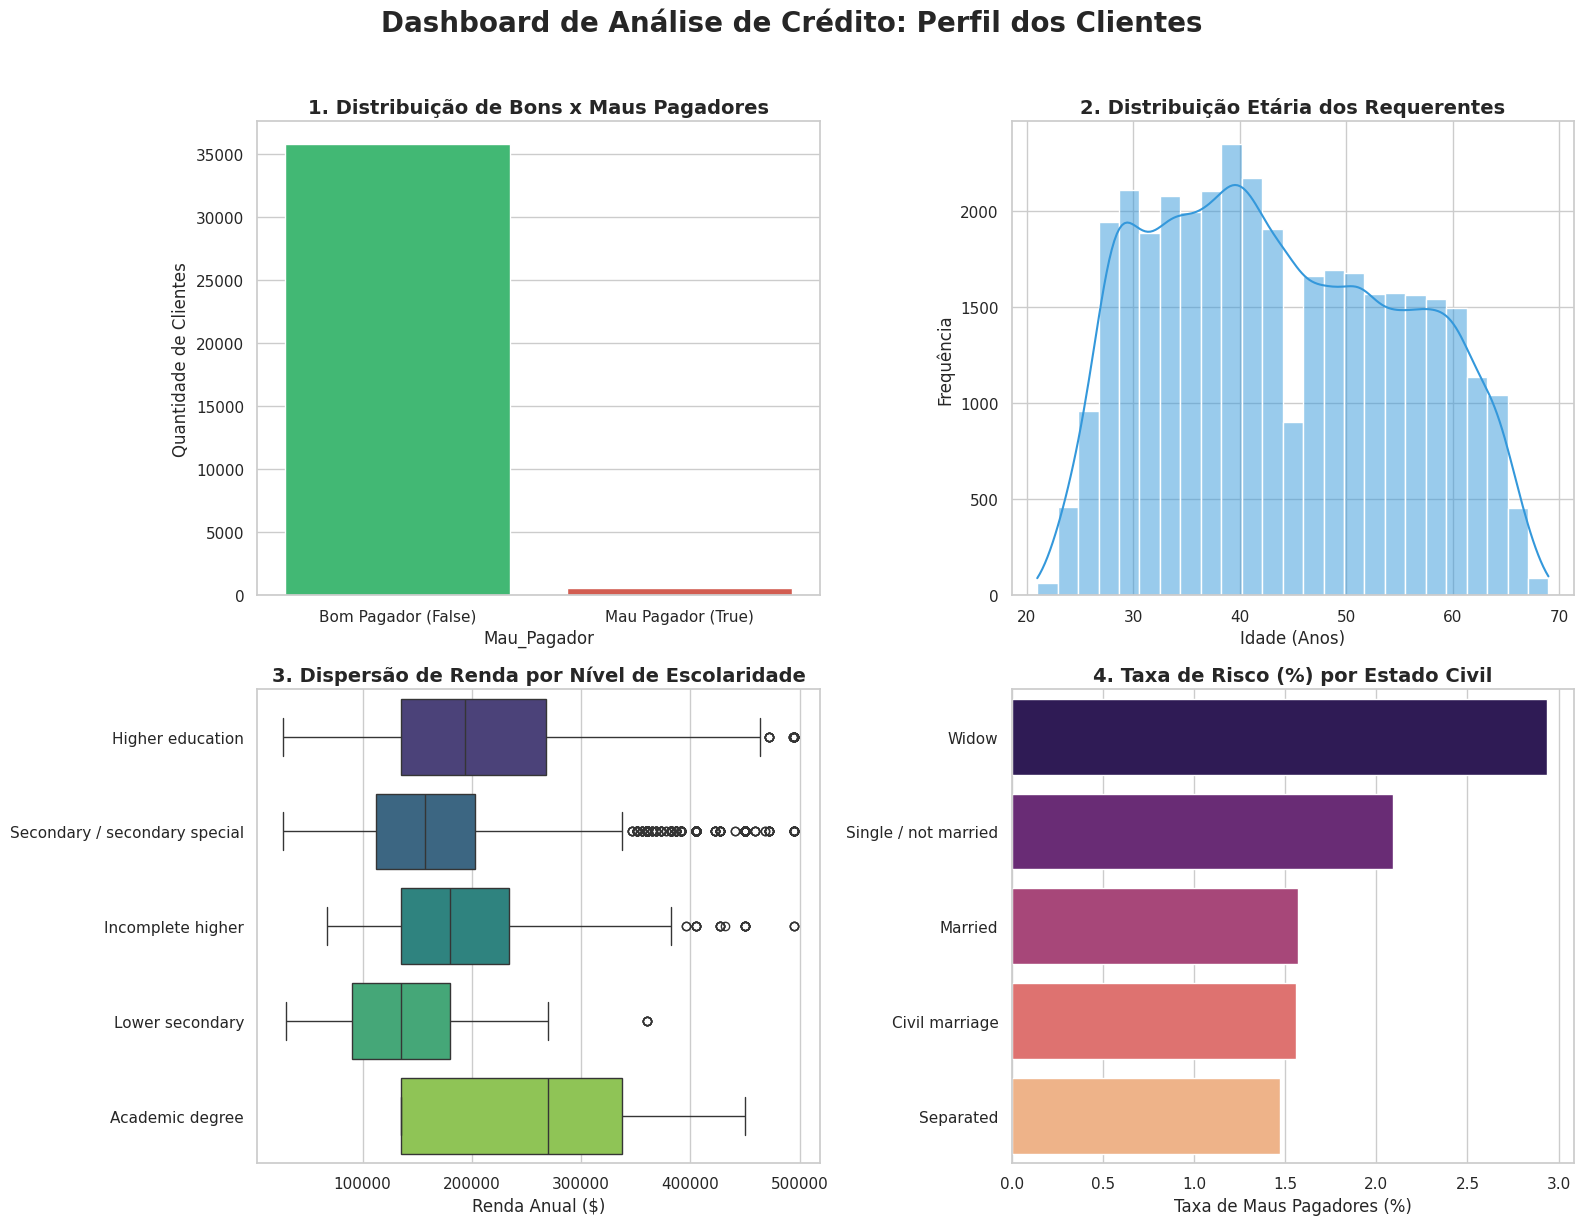

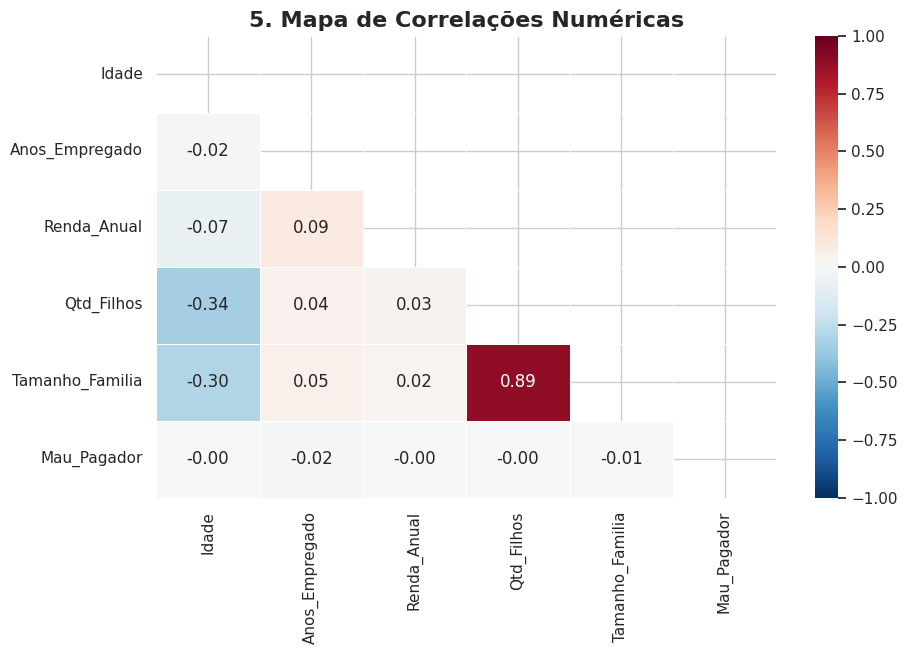

In [6]:
# ==========================================
# CÉLULA 2: ANÁLISE EXPLORATÓRIA VISUAL
# ==========================================

# Configurações visuais globais
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

# Cria um painel 2x2 para os gráficos
fig, axes = plt.subplots(2, 2)
fig.suptitle('Dashboard de Análise de Crédito: Perfil dos Clientes', fontsize=20, fontweight='bold', y=1.02)

# --- 1. O Problema do Desbalanceamento (Alvo) ---
sns.countplot(data=df, x='Mau_Pagador', palette=['#2ecc71', '#e74c3c'], ax=axes[0,0])
axes[0,0].set_title('1. Distribuição de Bons x Maus Pagadores', fontweight='bold', fontsize=14)
axes[0,0].set_xticklabels(['Bom Pagador (False)', 'Mau Pagador (True)'])
axes[0,0].set_ylabel('Quantidade de Clientes')

# --- 2. Distribuição da Idade ---
sns.histplot(data=df, x='Idade', kde=True, bins=25, color='#3498db', ax=axes[0,1])
axes[0,1].set_title('2. Distribuição Etária dos Requerentes', fontweight='bold', fontsize=14)
axes[0,1].set_xlabel('Idade (Anos)')
axes[0,1].set_ylabel('Frequência')

# --- 3. Renda Anual x Nível de Escolaridade ---
# Filtramos rendas absurdas (> 500k) apenas para o gráfico não achatar
renda_filtrada = df[df['Renda_Anual'] < 500000]
sns.boxplot(data=renda_filtrada, y='Escolaridade', x='Renda_Anual', palette='viridis', ax=axes[1,0])
axes[1,0].set_title('3. Dispersão de Renda por Nível de Escolaridade', fontweight='bold', fontsize=14)
axes[1,0].set_xlabel('Renda Anual ($)')
axes[1,0].set_ylabel('')

# --- 4. Taxa de Inadimplência por Estado Civil ---
# Calcula o percentual de caloteiros em cada estado civil
taxa_estado_civil = df.groupby('Estado_Civil')['Mau_Pagador'].mean().sort_values(ascending=False) * 100
sns.barplot(x=taxa_estado_civil.values, y=taxa_estado_civil.index, palette='magma', ax=axes[1,1])
axes[1,1].set_title('4. Taxa de Risco (%) por Estado Civil', fontweight='bold', fontsize=14)
axes[1,1].set_xlabel('Taxa de Maus Pagadores (%)')
axes[1,1].set_ylabel('')

plt.tight_layout()
plt.show()

# --- 5. Mapa de Calor (Correlação Numérica) ---
plt.figure(figsize=(10, 6))
cols_numericas = ['Idade', 'Anos_Empregado', 'Renda_Anual', 'Qtd_Filhos', 'Tamanho_Familia', 'Mau_Pagador']
correlacao = df[cols_numericas].corr(numeric_only=True)

# Máscara para plotar apenas a metade inferior do triângulo de correlação (estética premium)
mask = np.triu(np.ones_like(correlacao, dtype=bool))
sns.heatmap(correlacao, mask=mask, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)
plt.title('5. Mapa de Correlações Numéricas', fontweight='bold', fontsize=16)
plt.show()

In [7]:
# ==========================================
# CÉLULA 3: SEPARAÇÃO E CODIFICAÇÃO DOS DADOS
# ==========================================

X = df.drop(columns=['ID','Mau_Pagador'])
y = df['Mau_Pagador']

# Separação treino/teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Seleciona colunas categóricas
cat_cols = X_train.select_dtypes(include=['object']).columns

# O Target Encoding foi escolhido porque converte categorias em valores numéricos considerando sua relação com a variável alvo Mau_Pagador. Essa técnica é útil quando existem muitas categorias, pois evita aumentar muito a quantidade de colunas como aconteceria no One-Hot Encoding. Para evitar vazamento de dados, o encoder é treinado apenas com os dados de treino.
targetencoder = TargetEncoder(cols=cat_cols)

# Ajusta o encoder apenas no treino e aplica a mesma transformação no teste
X_train = targetencoder.fit_transform(X_train, y_train)
X_test = targetencoder.transform(X_test)

# Colunas numéricas que receberão RobustScaler
cols_robust = ['Renda_Anual', 'Idade', 'Anos_Empregado', 'Qtd_Filhos']

# Aplicando RobustScaler apenas nas colunas selecionadas
# O RobustScaler foi escolhido porque essas variáveis podem conter valores extremos,
# especialmente renda anual e tempo de emprego. Ele utiliza mediana e intervalo
# interquartil, sendo menos sensível a outliers do que a padronização tradicional.
robust = RobustScaler()

X_train[cols_robust] = robust.fit_transform(X_train[cols_robust])
X_test[cols_robust] = robust.transform(X_test[cols_robust])

print("Variáveis de treino:")
display(X_train)

Variáveis de treino:


,Genero,Tem_Carro,Tem_Imovel,Qtd_Filhos,Renda_Anual,Tipo_Renda,Escolaridade,Estado_Civil,Tipo_Moradia,Idade,Anos_Empregado,Tem_Celular,Tem_Tel_Trabalho,Tem_Tel_Fixo,Tem_Email,Profissao,Tamanho_Familia
1315,0.015285,1,1,0.0,0.000000,0.015900,0.016674,0.015588,0.016727,-0.368421,1.500,1,1,0,0,0.020884,2.0
22248,0.015285,0,1,0.0,1.304348,0.015900,0.016486,0.020955,0.016727,-0.052632,-0.500,1,0,0,0,0.016271,1.0
9791,0.015285,1,0,2.0,-0.652174,0.009976,0.016486,0.015588,0.016727,-0.789474,0.250,1,1,0,0,0.020884,4.0
10178,0.020135,0,1,2.0,5.000000,0.009976,0.016674,0.015588,0.016727,-0.210526,1.875,1,0,1,0,0.025401,4.0
28564,0.015285,0,0,1.0,-0.652174,0.015900,0.016674,0.015588,0.016575,-0.789474,-0.125,1,0,0,0,0.016271,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11917,0.015285,0,0,2.0,-0.217391,0.019273,0.016674,0.015588,0.016727,-0.473684,1.000,1,1,1,0,0.016163,4.0
18744,0.015285,0,0,0.0,-0.652174,0.015900,0.016674,0.020955,0.016575,-0.789474,0.500,1,0,0,0,0.016163,1.0
35917,0.020135,1,1,0.0,0.608696,0.015900,0.016674,0.015588,0.016727,-0.631579,-0.375,1,1,0,0,0.025401,2.0
32353,0.020135,1,0,0.0,-0.173913,0.015900,0.016674,0.015588,0.016727,0.368421,2.250,1,1,1,0,0.025401,2.0


In [12]:
# ==========================================
# CÉLULA 4: MODELO RANDOM FOREST
# ==========================================

# O Random Forest foi escolhido por ser um algoritmo robusto de classificação,
# baseado na combinação de várias árvores de decisão.
# Ele consegue capturar relações não lineares entre as variáveis,
# reduz o risco de overfitting em comparação com uma única árvore
# e funciona bem em problemas com variáveis numéricas e categóricas codificadas.
# Como o problema envolve classificação de bons e maus pagadores,
# também foi usado class_weight='balanced' para ajudar o modelo a lidar
# com possível desbalanceamento entre as classes.

modelo_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42
)

# Treinamento do modelo
modelo_rf.fit(X_train, y_train)

# Predição das classes
y_pred = modelo_rf.predict(X_test)

# Predição das probabilidades da classe positiva: Mau_Pagador = 1
y_proba = modelo_rf.predict_proba(X_test)[:, 1]

print("✅ Modelo Random Forest treinado com sucesso!")

✅ Modelo Random Forest treinado com sucesso!


In [13]:
# ==========================================
# CÉLULA 5: AVALIAÇÃO DO MODELO
# ==========================================

# Métricas principais
acuracia = accuracy_score(y_test, y_pred)
precisao = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("===== MÉTRICAS DO RANDOM FOREST =====")
print(f"Acurácia:  {acuracia:.4f}")
print(f"Precisão:  {precisao:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

print("\n===== RELATÓRIO DE CLASSIFICAÇÃO =====")
print(classification_report(
    y_test,
    y_pred,
    target_names=['Bom Pagador', 'Mau Pagador']
))

===== MÉTRICAS DO RANDOM FOREST =====
Acurácia:  0.9632
Precisão:  0.1926
Recall:    0.3676
F1-score:  0.2528
ROC-AUC:   0.7318

===== RELATÓRIO DE CLASSIFICAÇÃO =====
              precision    recall  f1-score   support

 Bom Pagador       0.99      0.97      0.98     10753
 Mau Pagador       0.19      0.37      0.25       185

    accuracy                           0.96     10938
   macro avg       0.59      0.67      0.62     10938
weighted avg       0.98      0.96      0.97     10938



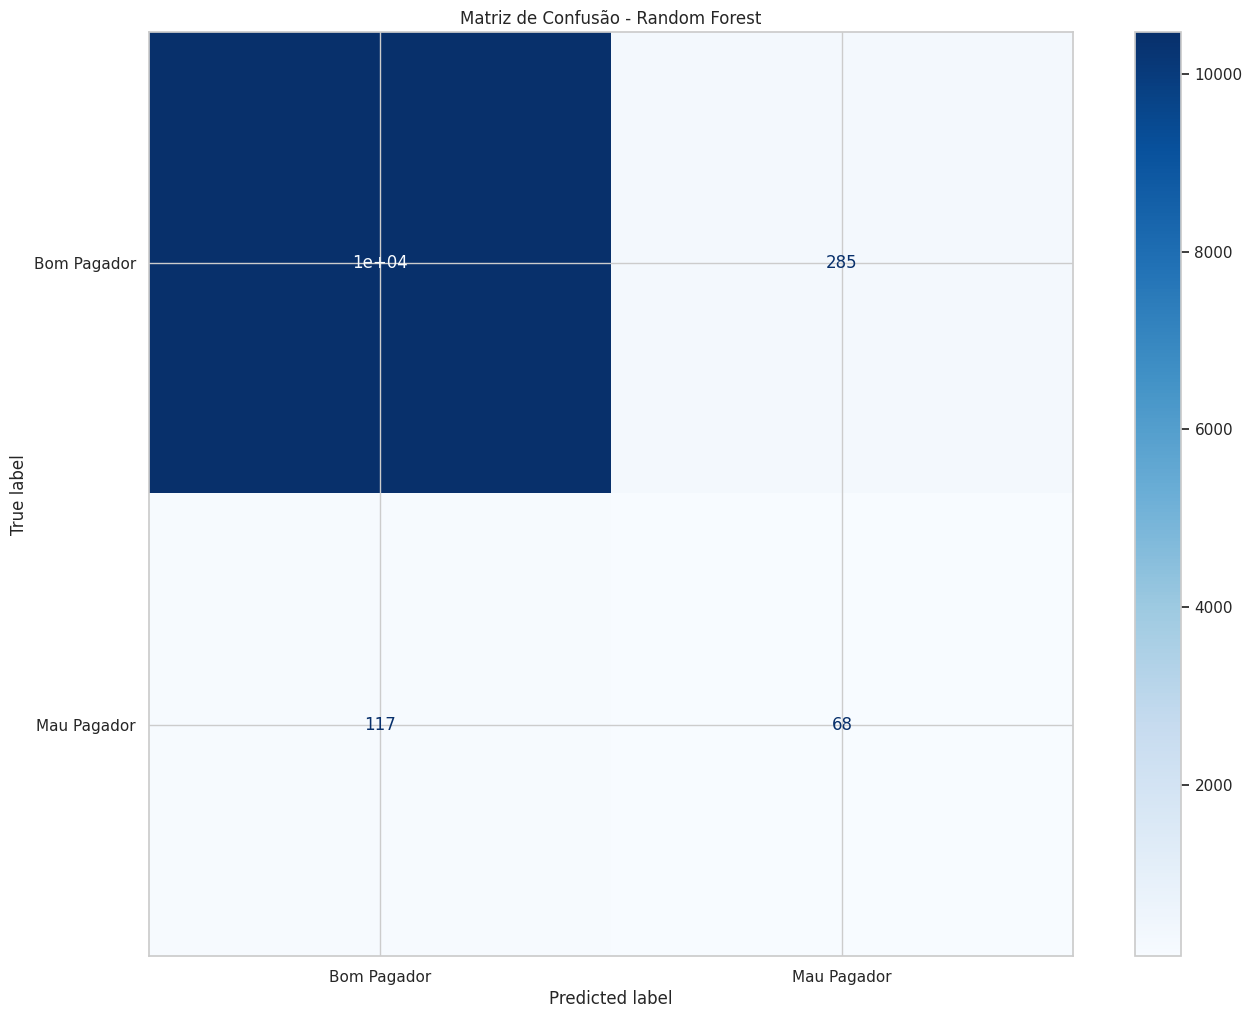

In [14]:
# ==========================================
# CÉLULA 6: MATRIZ DE CONFUSÃO
# ==========================================

matriz = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=['Bom Pagador', 'Mau Pagador']
)

disp.plot(cmap='Blues')
plt.title("Matriz de Confusão - Random Forest")
plt.show()

Variáveis mais importantes para o modelo:


,Variavel,Importancia
9,Idade,0.190474
4,Renda_Anual,0.180915
10,Anos_Empregado,0.139489
15,Profissao,0.101309
7,Estado_Civil,0.048362
5,Tipo_Renda,0.046241
16,Tamanho_Familia,0.043779
6,Escolaridade,0.039637
1,Tem_Carro,0.032574
13,Tem_Tel_Fixo,0.031142


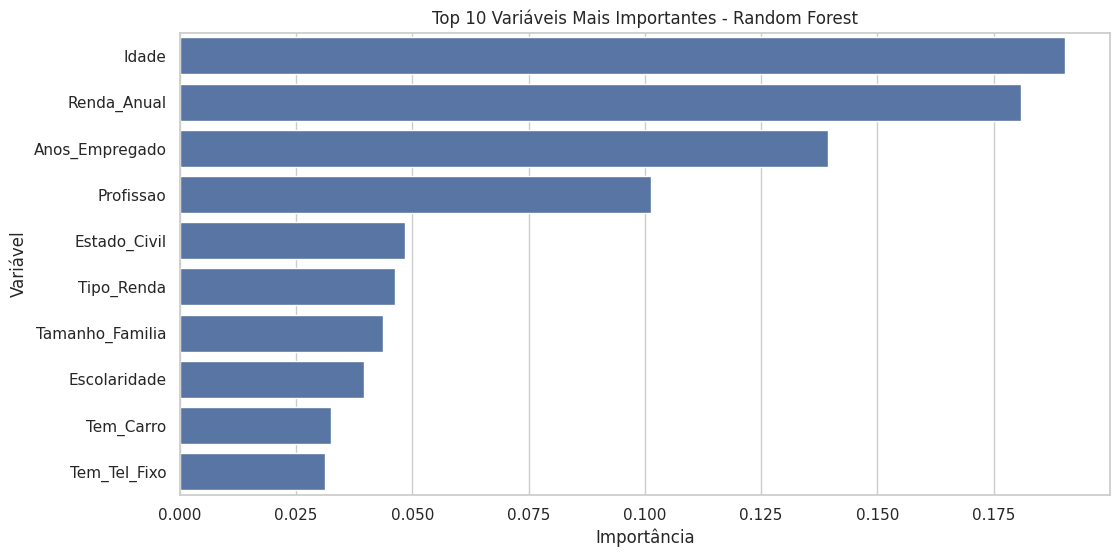

In [15]:
# ==========================================
# CÉLULA 7: IMPORTÂNCIA DAS VARIÁVEIS
# ==========================================

importancias = pd.DataFrame({
    'Variavel': X_train.columns,
    'Importancia': modelo_rf.feature_importances_
})

importancias = importancias.sort_values(by='Importancia', ascending=False)

print("Variáveis mais importantes para o modelo:")
display(importancias)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=importancias.head(10),
    x='Importancia',
    y='Variavel'
)

plt.title("Top 10 Variáveis Mais Importantes - Random Forest")
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.show()